# Customer Churn Prediction Model

## Business understanding
Financial institutions rely on long-term customer relationships to maintain profitability and business growth. However, some customers discontinue using the institution's products and services over time, leading to customer churn. High customer churn results in reduced revenue, increased customer acquisition costs, and lower customer lifetime value.
## Problem
Currently, many financial institutions lack a data-driven approach to identify customers who are likely to leave before they actually do. This limits their ability to implement timely customer retention strategies.
## Solution
This project aims to analyze customer data and develop a machine learning model capable of predicting customer churn. By identifying customers who are at risk of leaving, the institution can implement targeted retention initiatives, improve customer satisfaction and strengthen long-term customer relationships.

In [28]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.tree import plot_tree
import joblib
import streamlit as st


After importing the necessary libraries we import the data and clean it . we also perform some exploratory data analysis to understand the data better. We then split the data into training and testing sets, and train a machine learning model to predict customer churn. Finally, we evaluate the model's performance using cross-validation and classification metrics.

In [29]:
# Load the dataset
df=pd.read_csv('Customer_Churn_Model.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [30]:
# Check the data 
df.describe()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

From the dataset, we can see that there are 14 columns and 10,000 rows. The target variable is 'Exited'. The data types that the data exhibits are 
integer, float and object implying that there are both numerical and non numerical features.

## Data Quality Validation

In [31]:
# Data Quality Check
df.isnull().sum()
df.duplicated().sum()
df.shape


(10000, 14)

No null values and no duplicates found in the dataset.we can proceed to outlier detection and removal. The shape of the dataframe is 10000 rows and 14 columns before checking for outliers.


### Outlier Detection and Removal

In [32]:
 
# Outlier detection 
outlier_columns =['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    outliers = df[df[col].between(lower_bound, upper_bound)]
    print(f"Column: {col}, Outliers: {len(df)-len(outliers)}")




Column: CreditScore, Outliers: 15
Column: Age, Outliers: 359
Column: Balance, Outliers: 0
Column: NumOfProducts, Outliers: 60
Column: EstimatedSalary, Outliers: 0


I used IQR Method to detect Outliers and found that some features have outliers, but we will not remove them as they may contain important information about the customers.


## Exploratory Data Analysis

<Axes: xlabel='Exited', ylabel='count'>

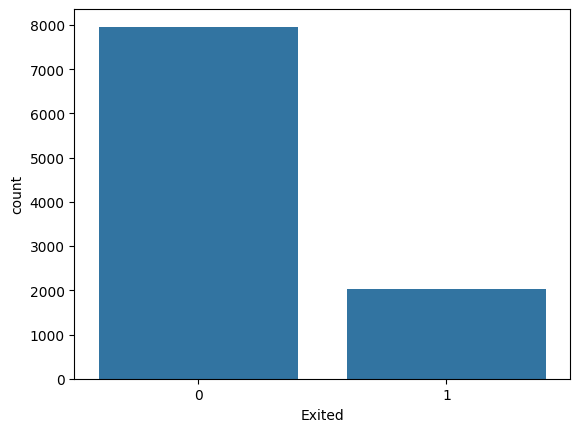

In [33]:
# Check target variable distribution
sns.countplot(x='Exited',data=df)


From the plot we realize that most customers were retained(0) and a few customers left(1). This is an imbalanced dataset. 
We will need to address this issue before training our model.

array([[<Axes: title={'center': 'RowNumber'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>, <Axes: >]], dtype=object)

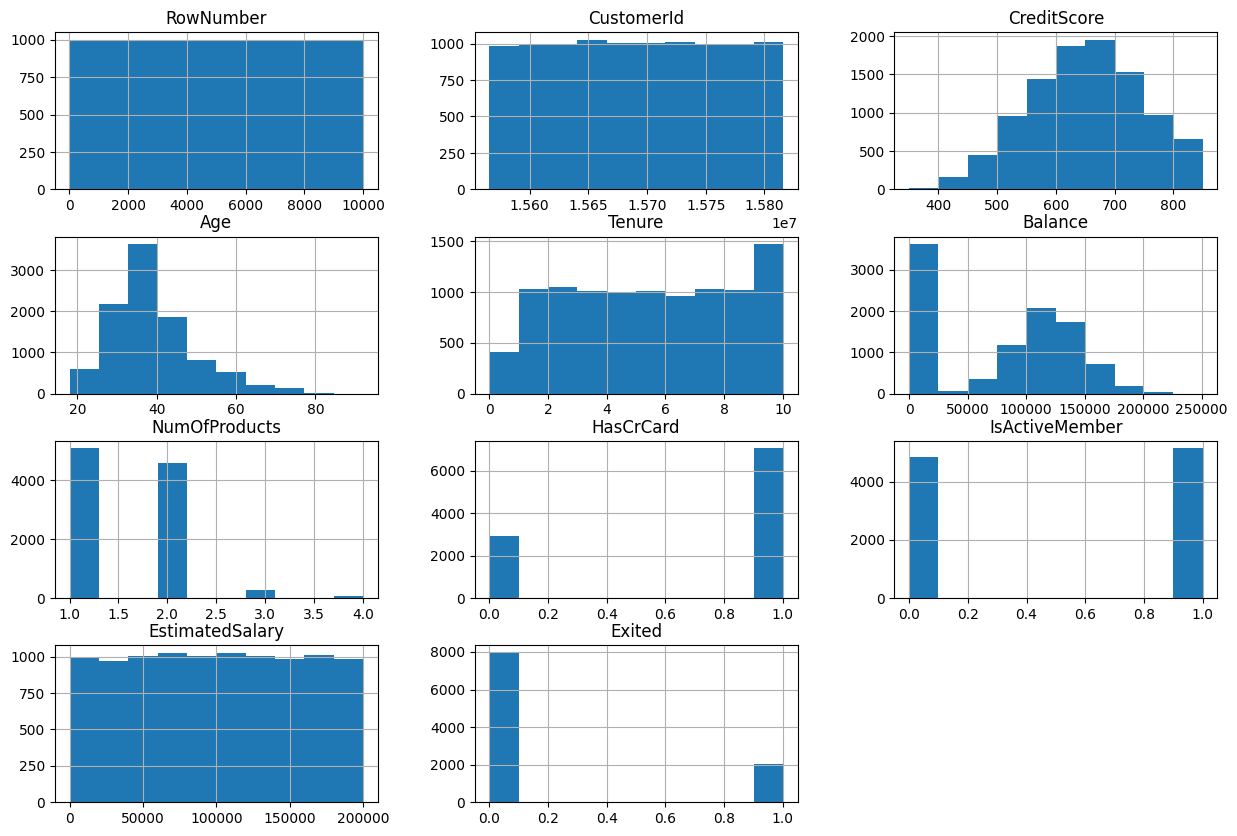

In [34]:
# Numerical features Distribution
df.hist(figsize=(15,10))

In [35]:
# Skewness check
df.skew(numeric_only=True)

RowNumber          0.000000
CustomerId         0.001149
CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64

From the analysis we realize that RowNumber, CustomerId, EstimatedSalary and Tenure are not skewed.Meaning they are symmetric. The features Age and Exited are highly positively skewed this is because Age captures a continous value and we could be having elderly aged customers explaining the larger age values. For the Exited Variable, it is encoded into 0 or 1 implying 0 for the customers who stayed and 1 for the customers who left.That shows that more customers stayed no wonder the larger values.
The features with skewness values of between -0.5 and 0.5 are moderately skewed.

In [36]:
# Kurtosis
df.kurtosis(numeric_only=True)

RowNumber         -1.200000
CustomerId        -1.196113
CreditScore       -0.425726
Age                1.395347
Tenure            -1.165225
Balance           -1.489412
NumOfProducts      0.582981
HasCrCard         -1.186973
IsActiveMember    -1.996747
EstimatedSalary   -1.181518
Exited             0.165671
dtype: float64

From the analysis we find that,our target variable, 'Exited' has a kurtosis value that is closer to zero (it is mesokurtic) meaning that the outlier character of the data set is similar to that of the normal distribution. Most Variables have a kurtosis value that is negative (platykurtic) meaning that the data set has lesser outliers (extreme values).Only Age is leptokurtic meaning that the data is too pointy.

<Axes: >

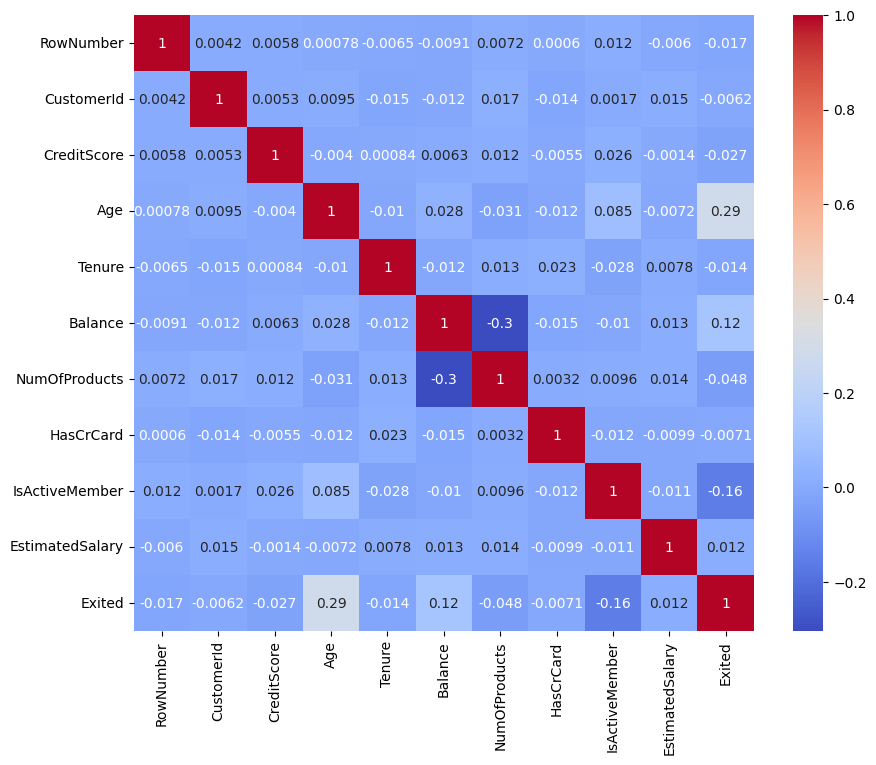

In [37]:
# Correlation of numerical features
corr=df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")

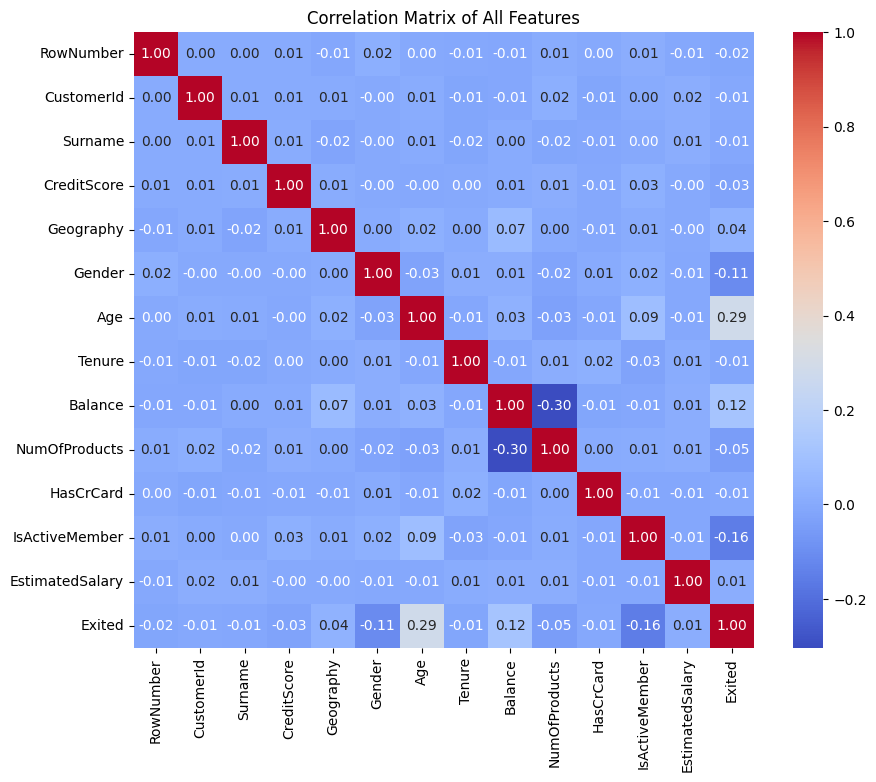

In [38]:
# Encode categorical Variables
df_encoded = df.copy()  
encoded_columns = df_encoded.select_dtypes(include=['object']).columns.tolist()
for column in encoded_columns:
    df_encoded[column] = LabelEncoder().fit_transform(df_encoded[column])
# Correlation matrix of all features
corr_all = df_encoded.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_all,cmap="coolwarm",annot=True, fmt='.2f')
plt.title("Correlation Matrix of All Features")
plt.show()

### Categorical Analysis

<Axes: xlabel='Gender', ylabel='count'>

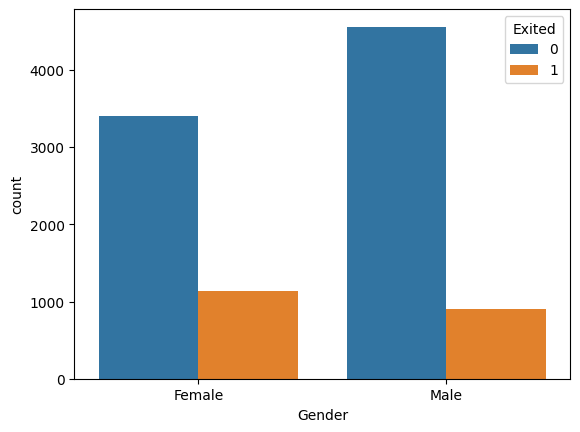

In [69]:
# Gender vs Exited
sns.countplot(x='Gender',hue='Exited',data=df)


From the Visualization we can see that more females than males exited the bank and more males than females stayed.
This implies that gender could have an effect on whether a customer exits the bank or not.

<Axes: xlabel='HasCrCard', ylabel='count'>

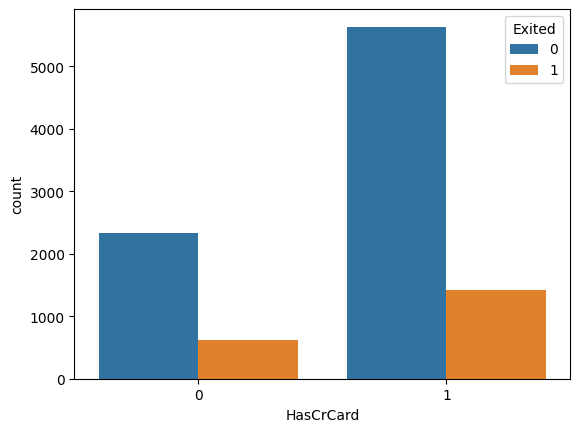

In [70]:
# Has Credit Card vs Exited
sns.countplot(x='HasCrCard',hue='Exited',data=df)

From the visualization above, we see that most clients with a credit card have not exited while most client without credit 
card have exited the bank. This shows that having a credit card is a good indicator of whether a customer will exxit or not.


<Axes: xlabel='IsActiveMember', ylabel='count'>

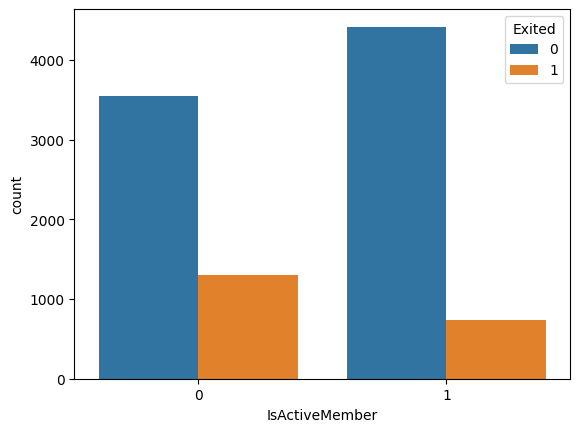

In [71]:
# IsActive Member vs Exited
sns.countplot(x='IsActiveMember',hue='Exited',data=df)

From this plot we see that most clients who are active members stay while those who are not active members are more likely
to exit. This is a very important feature to consider when building our model.

<Axes: xlabel='Tenure', ylabel='count'>

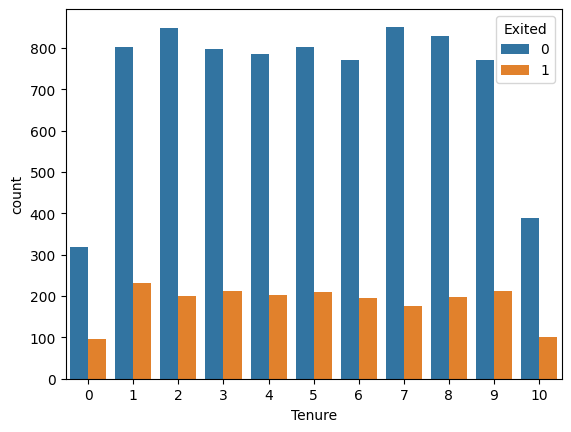

In [72]:
# Tenure vs Exited
sns.countplot(x='Tenure',hue='Exited',data=df)

From the analysis above, we can see that the customers who stay with the bank outnumber those who left across all tenure level.Customer churn occurs on 
both newly acquired customers and long term customers with no clear pattern. This implies that we can not predict whether a customer will churn or not based on Tenure alone. 
We need to consider other features as well.

Numerical Analysis

<Axes: xlabel='Age', ylabel='count'>

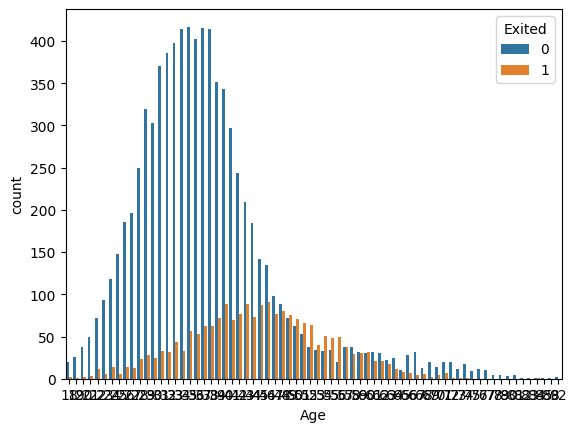

In [73]:
# Age vs Exited
sns.countplot(x='Age',hue='Exited',data=df)

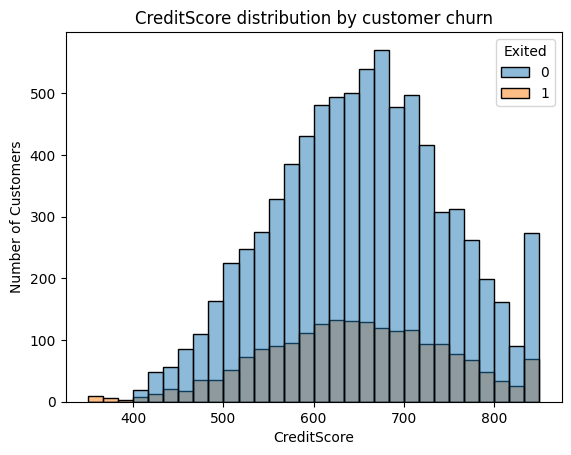

In [74]:
# CreditScore vs Exited
sns.histplot(x='CreditScore',hue='Exited',data=df, alpha=0.5, bins=30, multiple='layer')
plt.xlabel('CreditScore')
plt.ylabel('Number of Customers')
plt.title('CreditScore distribution by customer churn')
plt.show()

The gray is formed after orange(exited) mixes with blue(stayed). From the analysis the graph has no specific shape that we can say credit score distribution has a higher impact on whether a customer stays or leave as we can see we have customers with high credit score and they still leave and others with low credit score staying. This shows that there are other factors that determine whether a customer stays or leave.

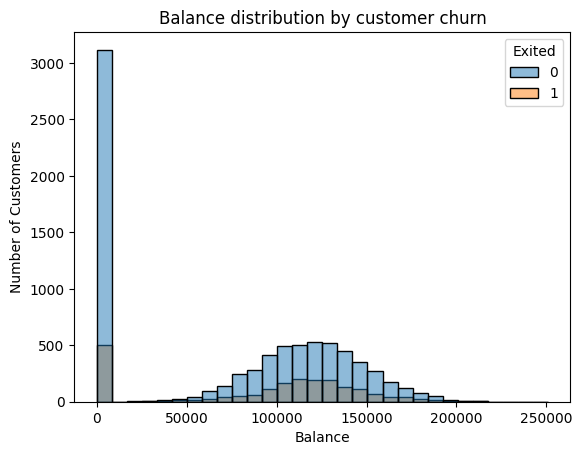

In [75]:
# Balance vs Exited
sns.histplot(x='Balance',hue='Exited',data=df, alpha=0.5, bins=30, multiple='layer')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.title('Balance distribution by customer churn')
plt.show()

As much as more customers stay when the balance is at zero we also realize that more customers exit when they have zero balance. this shows that there is a high chance that a customer won't leave if he/she has some balance even though others leave. we also see that as the balance increases the number of customers who exit also reduces. 

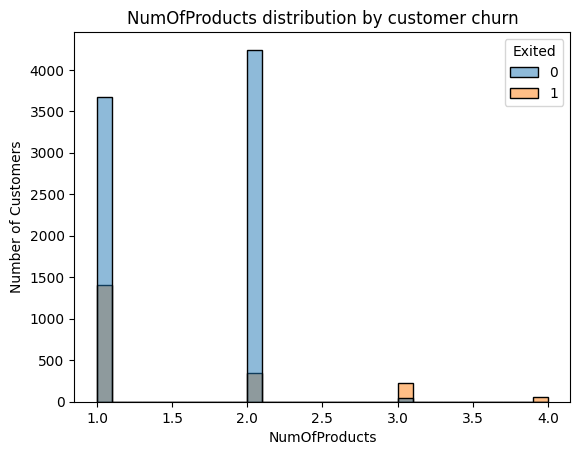

In [76]:
# NumOfProducts vs Exited
sns.histplot(x='NumOfProducts',hue='Exited',data=df, alpha=0.5, bins=30, multiple='layer')
plt.xlabel('NumOfProducts')
plt.ylabel('Number of Customers')
plt.title('NumOfProducts distribution by customer churn')
plt.show()

From the graph we find that the number of customers who exit reduce as the number of products a customer purchases increases

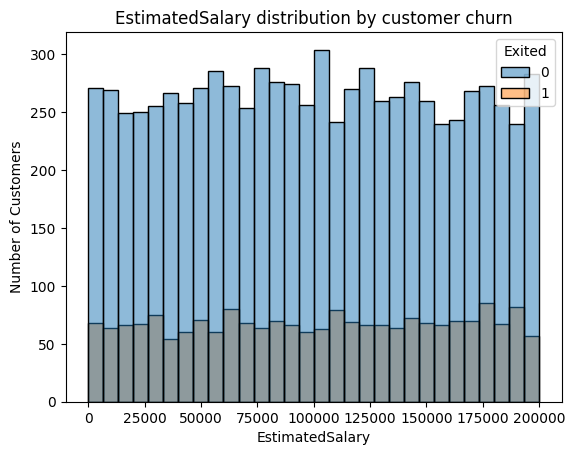

In [77]:
# EstimatedSalary vs Exited
sns.histplot(x='EstimatedSalary',hue='Exited',data=df, alpha=0.5, bins=30, multiple='layer')
plt.xlabel('EstimatedSalary')
plt.ylabel('Number of Customers')
plt.title('EstimatedSalary distribution by customer churn')
plt.show()

Estimated salary does not show any specific pattern that can help us define if customers might exit or not. This implies that it is a helping factor but alone it can't be used to predict customer churn.

### Multivariate Analysis

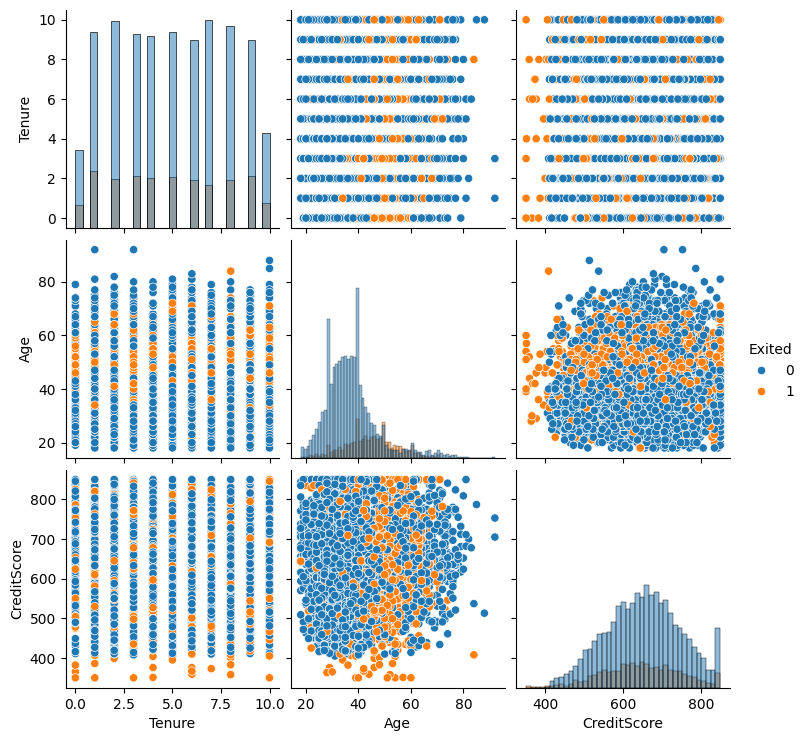

In [78]:
# Multivariate Analysis
pairplot_data=df[[ 'Tenure', 'Age', 'CreditScore',  'Exited']]
sns.pairplot(pairplot_data,hue='Exited',diag_kind='hist')
plt.show()

I used a pairplot to analyse how each feature variable relates with our target variable exited. Based on our results, we find that no matter the tenure, clients with low credit score have a higher probability of leaving.In addition, most middle aged clients have a higher probability of leaving (40- 70 yrs old) even if they have high credit score.  

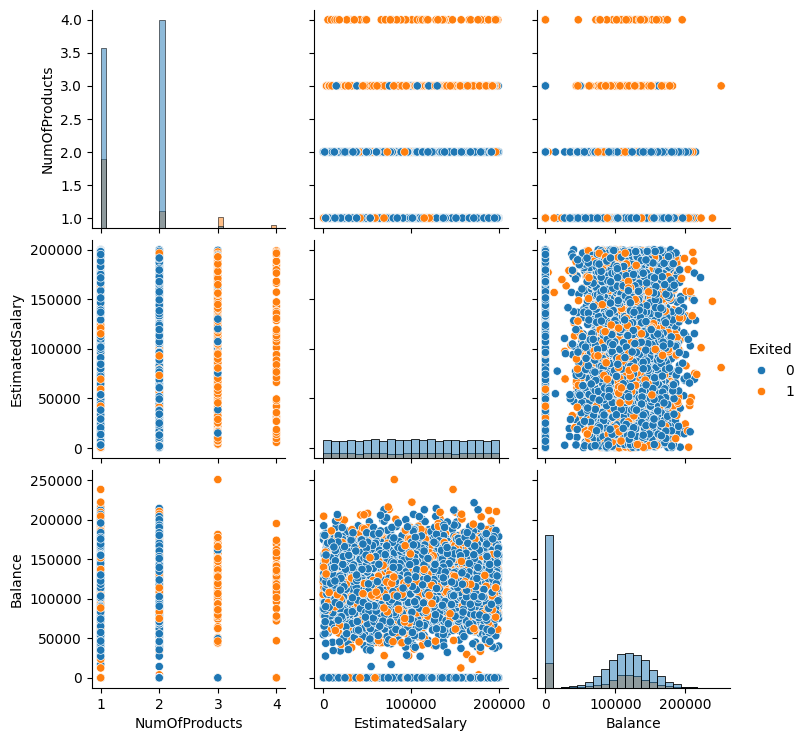

In [79]:
# Multivariate Analysis- Continuation
pairplot_data=df[[ 'NumOfProducts', 'EstimatedSalary', 'Balance', 'Exited']]
sns.pairplot(pairplot_data,hue='Exited',diag_kind='hist')
plt.show()

In this analysis we find that as the number of products a client purchases increases there is a high chance the customer may exit especially for the customers with a balance of between( 50,000-200000). Additionally, estimated salary does not show a specific pattern so it is supposed to be combined by other features to determine it's impact on whether a customer stays or exits.

## Data Pre processing

In [50]:
# Define feature categories
categorical_features = ["Geography", "Gender"]
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]
 # Create the text encoder preprocessor
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                  ("num", "passthrough", numerical_features)],
    remainder="drop",
)
# Bundle the encoder and model into a single Pipeline workflow
rf_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42))]
)


In [51]:
# Data splitting
X =df.drop(columns=["Exited", "RowNumber", "CustomerId","Surname"], axis=1)
y= df["Exited"]
X_train, X_test, y_train, y_test= train_test_split( X, y, test_size=0.2, random_state=42)


We splitted our data into 80/20 ratio where 80% is the training data and 20% the testing data. The feature variables are ( NumOfProducts, Balance, CreditScore,Geography, Age, Tenure, HasCrCard, EstimatedSalary,Gender, IsActiveMember,) while our target Variable is Exited

### Fitting

In [52]:
# Train the entire pipeline
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred = rf_pipeline.predict(X_test)


We built the model that we will use for predictions.( Random Forest) and we fit the data. But we need a baseline model for comparison but before that let's check this model's performance.

## Model Evaluation

In [53]:
# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(metrics.classification_report(y_test, y_pred))

Accuracy: 0.866
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.48      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



From the analysis the model makes 86.6% correct predictions to total predictions. The model makes 75% correct predictions that 
the customers may exit the bank.let's display the confusion matrix of this then compare this with other model to see which one suits our data better.


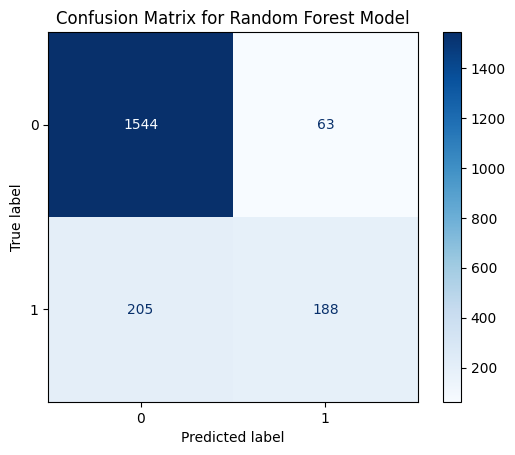

Random Forest Sensitivity: 0.47837150127226463


In [54]:
# confusion matrix
cm_display = ConfusionMatrixDisplay.from_estimator(rf_pipeline, X_test, y_test, cmap=plt.cm.Blues )
plt.title("Confusion Matrix for Random Forest Model")
plt.show()
# Sensitivity for Random Forest
rf_sensitivity = recall_score(y_test, y_pred)
print("Random Forest Sensitivity:", rf_sensitivity)

Logistic Regression Model

In [55]:
# Logistic Regression Model
log_pipeline = Pipeline(steps= [("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000, random_state=42))])
# Train The model
log_pipeline.fit(X_train, y_train)
# Prediction
log_predictions = log_pipeline.predict(X_test)


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
# Model Evaluation
accuracy = accuracy_score(y_test, log_predictions)
precision = precision_score(y_test, log_predictions)
recall = recall_score(y_test, log_predictions)

print("Logistic Regression Model Evaluation:")
print("Accuracy:", accuracy)
classification_report = metrics.classification_report(y_test, log_predictions)
print(classification_report)

Logistic Regression Model Evaluation:
Accuracy: 0.815
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.58      0.22      0.31       393

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



From the analysis, we see that the logistic regression model has an accuracy score of 81.5% which is less than that of our Random Forest model. This model shows 19% of correct predictions that customers will exit the bank. we can see the value is low because we generally have less instances of customers leaving the bank.
in General these values are low when compared to Random forest model so we will still use the Random Forest model since it predicts better. let's see the confusion matrix and sensitivity of this model so that we compare it with our previous model.

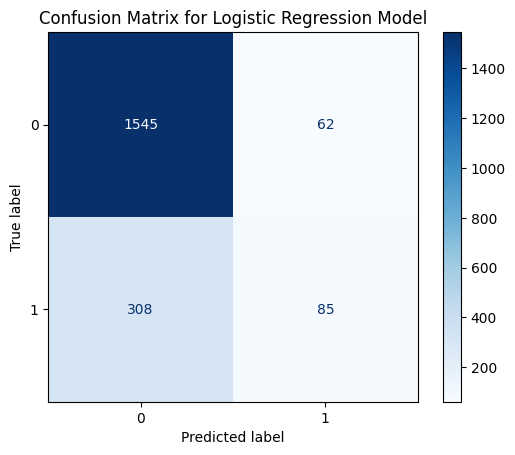

Logistic Regression Sensitivity: 0.21628498727735368


In [ ]:
# Confusion matrix 
cm_display = ConfusionMatrixDisplay.from_estimator(log_pipeline, X_test, y_test, cmap=plt.cm.Blues )
plt.title("Confusion Matrix for Logistic Regression Model")
plt.show()
# Sensitivity for Decision Tree
log_sensitivity = recall_score(y_test, log_predictions)
print("Logistic Regression Sensitivity:", log_sensitivity)

From This analysis, we can conclude that Random Forest model performed better since we are focusing on the ability of our model to predict those who will exit.
 Let's compare this with another model, Decision Tree.


Decision Tree

In [ ]:
# Decision Tree Model
dt_pipeline = Pipeline(steps= [("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))])
# Train the model
dt_pipeline.fit(X_train, y_train)
# Prediction
dt_prediction=dt_pipeline.predict(X_test)


In [ ]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, dt_prediction)
print("Accuracy:", accuracy)
# Evaluation Metrics
print("Decision Tree Classification Report")
dt_classification_report = metrics.classification_report(y_test, dt_prediction)
print(dt_classification_report)





Accuracy: 0.858
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.77      0.40      0.52       393

    accuracy                           0.86      2000
   macro avg       0.82      0.68      0.72      2000
weighted avg       0.85      0.86      0.84      2000



From the analysis we realise that the Decision Tree Has an accuracy 0f 85.8% . When compared to the Random forest model, this is slightly higher. wen you compare, this model shows 77% of correct predictions that customers will exit the bank . let's check it's confusion matrix and sensitivity before deciding on the best model to use.

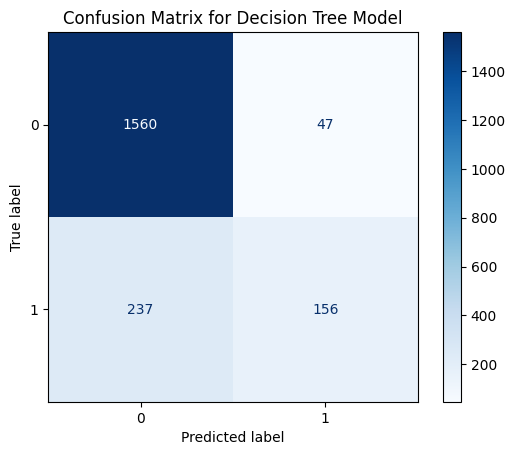

Decision Tree Sensitivity: 0.3969465648854962


In [ ]:
# Confusion matrix
cm_display = ConfusionMatrixDisplay.from_estimator(dt_pipeline, X_test, y_test, cmap=plt.cm.Blues )
plt.title("Confusion Matrix for Decision Tree Model")
plt.show()
# Sensitivity for Decision Tree
dt_sensitivity = recall_score(y_test, dt_prediction)
print("Decision Tree Sensitivity:", dt_sensitivity)

Although this model has better accuracy,the RF model makes more positive correct predictions compared to this model. Since our focus is on predicting correctly if a customer will exit the bank, RF model is suitable for our course. 

## MODEL SELECTION


After checking the sensitivity of all the models, RF model provides best sensitivity values thus the most suitable model for our analysis

# Model deployment

In [ ]:
# Save the rf model
joblib.dump(rf_pipeline, 'bank_churn_pipeline.pkl')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Load the saved model
model = joblib.load('bank_churn_pipeline.pkl')

In [ ]:
# Build the web interface
# interface title
st.title( " Customer Churn Prediction Dashboard")
st.write(" Enter the customer's attributes below to get an instant prediction")
print("success")

2026-07-20 13:51:36.542 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.628 
  command:

    streamlit run c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-20 13:51:38.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


success


In [ ]:
# Arrange layout into 2 columns
col1, col2 = st.columns(2)
with col1:
    credit_score = st.number_input(
        "Credit Score:", min_value=300, max_value=850, value=650
    )
    geography = st.selectbox("Geography / Country:", ["France", "Spain", "Germany"])
    gender = st.selectbox("Gender:", ["Male", "Female"])
    age = st.number_input("Age (Years):", min_value=18, max_value=200, value=35)
    tenure = st.slider("Tenure (Years with Bank):", min_value=0, max_value=10, value=5)
with col2:
    balance = st.number_input("Account Balance ($):", min_value=0.0, value=50000.0)
    num_products = st.selectbox("Number of Products Used:", [1, 2, 3, 4], index=0)
    has_cr_card = st.checkbox("Customer Has Credit Card?", value=True)
    is_active = st.checkbox("Is Customer an Active Member?", value=True)
    salary = st.number_input("Estimated Annual Salary ($):", min_value=0.0, value=75000.0)


2026-07-20 13:51:38.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:38.934 Session state does not function when running a script without `streamlit run`
2026-07-20 13:51

In [ ]:
# create the execution button
if st.button("Generate Model Prediction"):
    # Convert checkbox boolean values to binary 1s and 0s matching int64 formats
    has_card_int = 1 if has_cr_card else 0
    active_int = 1 if is_active else 0


2026-07-20 13:51:39.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# Structure user inputs into a structured DataFrame matching your exact column names
input_df = pd.DataFrame(
        [
            [
                credit_score,
                geography,
                gender,
                age,
                tenure,
                balance,
                num_products,
                has_cr_card,
                is_active,
                salary,
            ]
        ],
        columns=[
            "CreditScore",
            "Geography",
            "Gender",
            "Age",
            "Tenure",
            "Balance",
            "NumOfProducts",
            "HasCrCard",
            "IsActiveMember",
            "EstimatedSalary",
        ],
    )


In [ ]:

# Process through pipeline automatically (handles OneHotEncoding and Prediction internally)
prediction = rf_pipeline.predict(input_df)[0]
probability = rf_pipeline.predict_proba(input_df)[0][1]


In [ ]:
# Render results on screen
st.markdown("---")
if prediction == 1:
        st.error(
            f"**High Risk Alert**: Customer predicted to churn. (Probability: {probability:.2%})"
        )
else:
        st.success(
            f"**Low Risk**: Customer predicted to stay active. (Retention Probability: {1 - probability:.2%})"
        )


2026-07-20 13:51:39.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-20 13:51:39.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
